# 🎨 VecGlypher — Генерация векторных глифов
Запускайте ячейки по порядку сверху вниз. Каждую ячейку запускать кнопкой ▶ или `Shift+Enter`.

---
## Шаг 1 — Настройки
Запустите один раз в начале.

In [8]:
import requests, json, os, base64, zipfile, glob
from IPython.display import display, HTML
from pathlib import Path
from datetime import datetime

# ============================================================
# НАСТРОЙКИ — измените под себя
# ============================================================
MODEL_PATH = "/workspace/VecGlypher/saves/VecGlypher-27b-it"
SERVER_PORT = 30000
SERVER_URL  = f"http://localhost:{SERVER_PORT}/v1"
OUTPUT_DIR  = "/workspace/VecGlypher/outputs"

# Папки для референсов (проверяются по порядку)
REF_SEARCH_PATHS = [
    "/workspace/ref",
    "/workspace/VecGlypher/ref",
]
# Папки где искать zip архив с референсами
ZIP_SEARCH_PATHS = [
    "/workspace",
    "/workspace/VecGlypher",
]

# Параметры генерации
TEMPERATURE        = 0.7
TOP_P              = 0.8
TOP_K              = 20
MAX_TOKENS         = 2048
REPETITION_PENALTY = 1.05

SYSTEM_PROMPT = """You are a specialized vector glyph designer creating SVG path elements.

CRITICAL REQUIREMENTS:
- Each glyph must be a complete, self-contained element, in reading order of the given text.
- Terminate each element with a newline character
- Output ONLY valid SVG elements"""

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Вспомогательные функции
# ------------------------------------------------------------
def img_to_base64(path):
    ext = Path(path).suffix.lower()
    mime = "image/png" if ext == ".png" else "image/jpeg"
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    return f"data:{mime};base64,{b64}"

def find_ref_folder():
    for path in REF_SEARCH_PATHS:
        if os.path.isdir(path):
            files = [f for f in os.listdir(path) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
            if files:
                return path, files
    return None, []

def find_zip():
    for folder in ZIP_SEARCH_PATHS:
        zips = glob.glob(f"{folder}/*.zip")
        if zips:
            return zips[0]
    return None

def generate_glyph_text(character, font_style):
    """Text-referenced: генерирует глиф по текстовому описанию стиля."""
    response = requests.post(
        f"{SERVER_URL}/chat/completions",
        headers={"Content-Type": "application/json", "Authorization": "dummy-key"},
        json={
            "model": MODEL_PATH,
            "messages": [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Font design requirements: {font_style}\nText content: {character}"}
            ],
            "temperature": TEMPERATURE, "top_p": TOP_P, "top_k": TOP_K,
            "min_p": 0.0, "repetition_penalty": REPETITION_PENALTY,
            "chat_template_kwargs": {"enable_thinking": False},
            "max_tokens": MAX_TOKENS
        },
        timeout=120
    )
    result = response.json()
    if "choices" not in result:
        print("❌ Ошибка от сервера:")
        print(json.dumps(result, indent=2))
        raise KeyError("choices")
    svg_paths = result["choices"][0]["message"]["content"]
    full_svg = f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="-50 -50 1100 1100" width="300" height="300">\n  <rect x="-50" y="-50" width="1100" height="1100" fill="white"/>\n  <g fill="black" stroke="none">{svg_paths}</g>\n</svg>'
    safe_style = font_style[:20].replace(' ', '_').replace(',', '')
    filename = f"{OUTPUT_DIR}/glyph_{character}_{safe_style}.svg"
    with open(filename, "w") as f:
        f.write(full_svg)
    return full_svg, filename

def generate_glyph_image(character, ref_image_paths):
    """Image-referenced: генерирует глиф по референсным изображениям."""
    user_content = []
    for img_path in ref_image_paths:
        user_content.append({
            "type": "image_url",
            "image_url": {"url": img_to_base64(img_path)}
        })
    user_content.append({
        "type": "text",
        "text": f"Text content: {character}"
    })
    response = requests.post(
        f"{SERVER_URL}/chat/completions",
        headers={"Content-Type": "application/json", "Authorization": "dummy-key"},
        json={
            "model": MODEL_PATH,
            "messages": [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_content}
            ],
            "temperature": TEMPERATURE, "top_p": TOP_P, "top_k": TOP_K,
            "min_p": 0.0, "repetition_penalty": REPETITION_PENALTY,
            "chat_template_kwargs": {"enable_thinking": False},
            "max_tokens": MAX_TOKENS
        },
        timeout=120
    )
    result = response.json()
    if "choices" not in result:
        print("❌ Ошибка от сервера:")
        print(json.dumps(result, indent=2))
        raise KeyError("choices")
    svg_paths = result["choices"][0]["message"]["content"]
    full_svg = f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="-50 -50 1100 1100" width="300" height="300">\n  <rect x="-50" y="-50" width="1100" height="1100" fill="white"/>\n  <g fill="black" stroke="none">{svg_paths}</g>\n</svg>'
    safe_name = character if character.isupper() else f"{character}_"
    filename = f"{OUTPUT_DIR}/{safe_name}.svg"
    with open(filename, "w") as f:
        f.write(full_svg)
    return full_svg, filename

print("✅ Настройки загружены")
print(f"   Модель : {MODEL_PATH}")
print(f"   Сервер : {SERVER_URL}")
print(f"   Папка  : {OUTPUT_DIR}")


✅ Настройки загружены
   Модель : /workspace/VecGlypher/saves/VecGlypher-27b-it
   Сервер : http://localhost:30000/v1
   Папка  : /workspace/VecGlypher/outputs


---
## Шаг 2 — Проверка сервера

In [9]:
try:
    r = requests.get(f"{SERVER_URL}/models", timeout=3)
    models = r.json()
    print("✅ Сервер работает!")
    print(f"   Модель: {models['data'][0]['id']}")
except Exception as e:
    print(f"❌ Сервер недоступен: {e}")
    print("   Запустите vLLM: vllm serve saves/VecGlypher-27b-it --port 30000")


✅ Сервер работает!
   Модель: /workspace/VecGlypher/saves/VecGlypher-27b-it


---
## Шаг 3 — Генерация одного символа (text-referenced)

In [10]:
# ✏️ МЕНЯЙТЕ ЭТИ ПАРАМЕТРЫ
CHARACTER  = "A"
FONT_STYLE = "humanist sans-serif, 600 weight, calm, competent, business"

print(f"🎨 Генерируем '{CHARACTER}'...")
full_svg, filename = generate_glyph_text(CHARACTER, FONT_STYLE)
print(f"✅ Сохранено: {filename}")
display(HTML(full_svg))


🎨 Генерируем 'A'...
✅ Сохранено: /workspace/VecGlypher/outputs/glyph_A_humanist_sans-serif.svg


---
## Шаг 4 — Пакетная генерация (text-referenced)
Каждый символ сохраняется сразу после генерации.

In [ ]:
# ✏️ МЕНЯЙТЕ ЭТИ ПАРАМЕТРЫ
CHARACTERS_BATCH = ["A", "B", "C", "D", "E"]
FONT_STYLE_BATCH = "elegant serif, thin weight, luxury, fashion"

date_str = datetime.now().strftime("%Y-%m-%d")
base = Path(OUTPUT_DIR)
existing = [d for d in base.iterdir() if d.is_dir() and d.name.startswith(date_str)]
next_num = len(existing) + 1
batch_dir = str(base / f"{date_str}_{next_num:03d}_text")
Path(batch_dir).mkdir(parents=True, exist_ok=True)

print(f"📁 Папка: {batch_dir}")
results_html = "<div style='display:flex; flex-wrap:wrap; gap:15px; padding:10px;'>"
saved = []

for char in CHARACTERS_BATCH:
    print(f"  🎨 Генерируем '{char}'...", end=" ", flush=True)
    try:
        user_content = f"Font design requirements: {FONT_STYLE_BATCH}\nText content: {char}"
        response = requests.post(
            f"{SERVER_URL}/chat/completions",
            headers={"Content-Type": "application/json", "Authorization": "dummy-key"},
            json={
                "model": MODEL_PATH,
                "messages": [
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": user_content}
                ],
                "temperature": TEMPERATURE, "top_p": TOP_P, "top_k": TOP_K,
                "min_p": 0.0, "repetition_penalty": REPETITION_PENALTY,
                "chat_template_kwargs": {"enable_thinking": False},
                "max_tokens": MAX_TOKENS
            },
            timeout=120
        )
        result = response.json()
        if "choices" not in result:
            print(f"❌ {result.get('error', {}).get('message', result)}")
            continue
        svg_paths = result["choices"][0]["message"]["content"]
        full_svg = f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="-50 -50 1100 1100" width="300" height="300">\n  <rect x="-50" y="-50" width="1100" height="1100" fill="white"/>\n  <g fill="black" stroke="none">{svg_paths}</g>\n</svg>'
        safe_name = char if char.isupper() else f"{char}_"
        filename = f"{batch_dir}/{safe_name}.svg"
        with open(filename, "w") as f:
            f.write(full_svg)
        saved.append(filename)
        svg_small = full_svg.replace('width="300" height="300"', 'width="100" height="100"')
        results_html += f"<div style='text-align:center'>{svg_small}<br><b>{char}</b></div>"
        print(f"✅")
    except Exception as e:
        print(f"❌ {e}")

results_html += "</div>"
print(f"\n🏁 Сохранено {len(saved)} из {len(CHARACTERS_BATCH)}")
display(HTML(results_html))


---
## Шаг 5 — Работа с референсами (image-referenced)

### Шаг 5.1 — Загрузка референсов

In [11]:
ref_folder, ref_files = find_ref_folder()

if ref_folder:
    print(f"✅ Референсы найдены: {ref_folder}")
    print(f"   Файлов: {len(ref_files)}")
    for f in sorted(ref_files):
        print(f"   - {f}")
else:
    zip_path = find_zip()
    if zip_path:
        print(f"📦 Найден ZIP: {zip_path}")
        extract_dir = "/workspace/ref"
        os.makedirs(extract_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as z:
            for member in z.namelist():
                if member.lower().endswith((".png", ".jpg", ".jpeg")):
                    filename = os.path.basename(member)
                    if filename:
                        target = os.path.join(extract_dir, filename)
                        with z.open(member) as src, open(target, "wb") as dst:
                            dst.write(src.read())
        ref_folder, ref_files = find_ref_folder()
        if ref_folder:
            print(f"✅ Извлечено {len(ref_files)} файлов в {extract_dir}")
        else:
            print("❌ После извлечения файлы не найдены")
    else:
        print("❌ Референсы не найдены!")
        print("   Загрузите PNG/JPG файлы в /workspace/ref/")
        print("   или ZIP архив в /workspace/")


✅ Референсы найдены: /workspace/ref
   Файлов: 1
   - pixel-1.jpg


### Шаг 5.2 — Просмотр референсов

✅ Референсов: 1



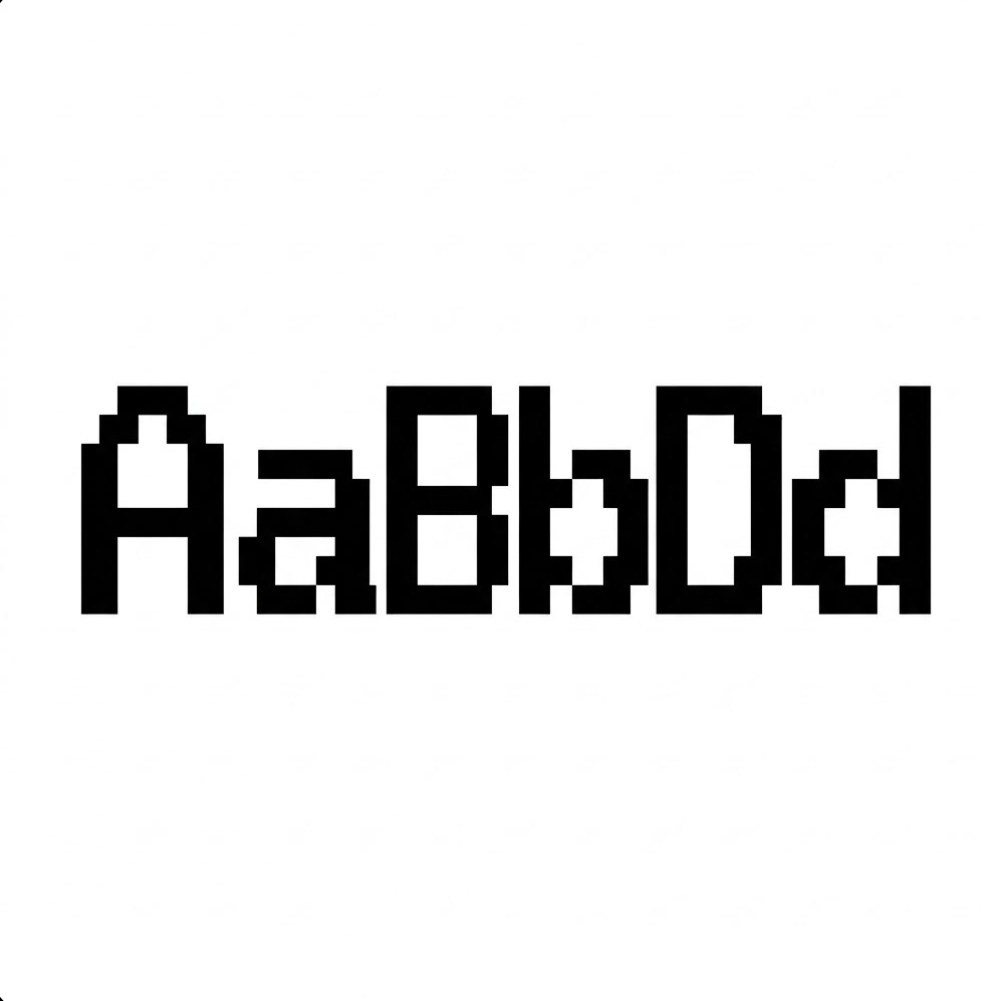

In [12]:
ref_folder, ref_files = find_ref_folder()
if not ref_folder:
    print("❌ Референсы не найдены!")
else:
    html = "<div style='display:flex; flex-wrap:wrap; gap:10px; padding:10px;'>"
    for fname in sorted(ref_files):
        fpath = f"{ref_folder}/{fname}"
        b64 = img_to_base64(fpath)
        html += f"<div style='text-align:center'><img src='{b64}' style='width:120px;height:120px;object-fit:contain;border:1px solid #ccc'/><br><small>{fname}</small></div>"
    html += "</div>"
    print(f"✅ Референсов: {len(ref_files)}")
    display(HTML(html))


### Шаг 5.3 — Генерация одного символа с референсами

In [13]:
# ✏️ МЕНЯЙТЕ ЭТОТ ПАРАМЕТР
CHARACTER_IMG = "A"

ref_folder, ref_files = find_ref_folder()
if not ref_folder:
    print("❌ Сначала загрузите референсы (Шаг 5.1)")
else:
    date_str = datetime.now().strftime("%Y-%m-%d")
    base = Path(OUTPUT_DIR)
    existing = [d for d in base.iterdir() if d.is_dir() and d.name.startswith(date_str)]
    next_num = len(existing) + 1
    example_dir = base / f"{date_str}_{next_num:03d}_example"
    example_dir.mkdir(parents=True, exist_ok=True)

    ref_paths = [f"{ref_folder}/{f}" for f in sorted(ref_files)]
    print(f"🎨 Генерируем '{CHARACTER_IMG}' с {len(ref_paths)} референсами...")

    user_content = []
    for img_path in ref_paths:
        user_content.append({"type": "image_url", "image_url": {"url": img_to_base64(img_path)}})
    user_content.append({"type": "text", "text": f"Text content: {CHARACTER_IMG}"})

    response = requests.post(
        f"{SERVER_URL}/chat/completions",
        headers={"Content-Type": "application/json", "Authorization": "dummy-key"},
        json={
            "model": MODEL_PATH,
            "messages": [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_content}
            ],
            "temperature": TEMPERATURE, "top_p": TOP_P, "top_k": TOP_K,
            "min_p": 0.0, "repetition_penalty": REPETITION_PENALTY,
            "chat_template_kwargs": {"enable_thinking": False},
            "max_tokens": MAX_TOKENS
        },
        timeout=120
    )
    result = response.json()
    if "choices" not in result:
        print("❌ Ошибка от сервера:")
        print(json.dumps(result, indent=2))
    else:
        svg_paths = result["choices"][0]["message"]["content"]
        full_svg = f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="-50 -50 1100 1100" width="300" height="300">\n  <rect x="-50" y="-50" width="1100" height="1100" fill="white"/>\n  <g fill="black" stroke="none">{svg_paths}</g>\n</svg>'
        safe_name = CHARACTER_IMG if CHARACTER_IMG.isupper() else f"{CHARACTER_IMG}_"
        filename = str(example_dir / f"{safe_name}.svg")
        with open(filename, "w") as f:
            f.write(full_svg)
        print(f"✅ Сохранено: {filename}")
        display(HTML(full_svg))


🎨 Генерируем 'A' с 1 референсами...
✅ Сохранено: /workspace/VecGlypher/outputs/2026-03-09_002_example/A.svg


### Шаг 5.4 — Пакетная генерация с референсами

In [14]:
import ipywidgets as widgets
import shutil

def make_batch_dir(batch_type):
    date_str = datetime.now().strftime("%Y-%m-%d")
    base = Path(OUTPUT_DIR)
    existing = [d for d in base.iterdir() if d.is_dir() and d.name.startswith(date_str)]
    next_num = len(existing) + 1
    folder_name = f"{date_str}_{next_num:03d}_{batch_type}"
    batch_dir = base / folder_name
    batch_dir.mkdir(parents=True, exist_ok=True)
    return str(batch_dir)

def get_output_folders():
    base = Path(OUTPUT_DIR)
    folders = []
    if base.exists():
        for d in sorted(base.iterdir()):
            if d.is_dir() and list(d.glob("*.svg")):
                folders.append(d.name)
    return folders

def generate_single(char, ref_paths, target_dir):
    user_content = []
    for img_path in ref_paths:
        user_content.append({"type": "image_url", "image_url": {"url": img_to_base64(img_path)}})
    user_content.append({"type": "text", "text": f"Text content: {char}"})
    response = requests.post(
        f"{SERVER_URL}/chat/completions",
        headers={"Content-Type": "application/json", "Authorization": "dummy-key"},
        json={
            "model": MODEL_PATH,
            "messages": [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_content}
            ],
            "temperature": TEMPERATURE, "top_p": TOP_P, "top_k": TOP_K,
            "min_p": 0.0, "repetition_penalty": REPETITION_PENALTY,
            "chat_template_kwargs": {"enable_thinking": False},
            "max_tokens": MAX_TOKENS
        },
        timeout=120
    )
    result = response.json()
    if "choices" not in result:
        raise Exception(result.get("error", {}).get("message", str(result)))
    svg_paths = result["choices"][0]["message"]["content"]
    full_svg = f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="-50 -50 1100 1100" width="300" height="300">\n  <rect x="-50" y="-50" width="1100" height="1100" fill="white"/>\n  <g fill="black" stroke="none">{svg_paths}</g>\n</svg>'
    safe_name = char if char.isupper() else f"{char}_"
    filename = f"{target_dir}/{safe_name}.svg"
    with open(filename, "w") as f:
        f.write(full_svg)
    return full_svg, filename

# --- Вкладка 1: Пакетная ---
mode = widgets.ToggleButtons(
    options=[
        ("🔠 Весь алфавит (A-Z + a-z)", "full"),
        ("🔡 Только заглавные (A-Z)", "upper"),
        ("🔤 Только строчные (a-z)", "lower"),
    ],
    description="Режим:",
    style={"description_width": "initial"}
)
run_btn = widgets.Button(description="🎨 Запустить генерацию", button_style="primary",
                         layout=widgets.Layout(width="220px", height="40px"))
batch_out = widgets.Output()

def on_run(b):
    with batch_out:
        batch_out.clear_output()
        ref_folder, ref_files = find_ref_folder()
        if not ref_folder:
            print("❌ Референсы не найдены! Сначала выполните Шаг 5.1")
            return
        ref_paths = [f"{ref_folder}/{f}" for f in sorted(ref_files)]
        if mode.value == "full":
            chars = list("ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz")
        elif mode.value == "upper":
            chars = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
        else:
            chars = list("abcdefghijklmnopqrstuvwxyz")
        batch_dir = make_batch_dir(mode.value)
        print(f"📋 Режим     : {mode.label}")
        print(f"📋 Символов  : {len(chars)}")
        print(f"📋 Референсов: {len(ref_paths)}")
        print(f"📁 Папка     : {batch_dir}")
        print()
        results_html = "<div style='display:flex; flex-wrap:wrap; gap:15px; padding:10px;'>"
        saved = []
        for char in chars:
            print(f"  🎨 '{char}'...", end=" ", flush=True)
            try:
                full_svg, filename = generate_single(char, ref_paths, batch_dir)
                saved.append(filename)
                svg_small = full_svg.replace('width="300" height="300"', 'width="100" height="100"')
                results_html += f"<div style='text-align:center'>{svg_small}<br><b>{char}</b></div>"
                print("✅")
            except Exception as e:
                print(f"❌ {e}")
        results_html += "</div>"
        print(f"\n🏁 Сохранено {len(saved)} из {len(chars)}")
        print(f"📁 {batch_dir}")
        display(HTML(results_html))
        folder_select.options = ["(новая папка)"] + get_output_folders()
        view_folder_select.options = get_output_folders()

run_btn.on_click(on_run)

# --- Вкладка 2: Отдельные буквы ---
chars_input = widgets.Text(value="A,b,C", description="Буквы:",
    placeholder="Например: A,b,C,d или просто AbCd",
    style={"description_width": "initial"}, layout=widgets.Layout(width="400px"))
folder_select = widgets.Dropdown(
    options=["(новая папка)"] + get_output_folders(),
    description="Папка:", style={"description_width": "initial"},
    layout=widgets.Layout(width="400px"))
single_run_btn = widgets.Button(description="🎨 Генерировать", button_style="primary",
                                layout=widgets.Layout(width="180px", height="40px"))
single_out = widgets.Output()

def on_single_run(b):
    with single_out:
        single_out.clear_output()
        ref_folder, ref_files = find_ref_folder()
        if not ref_folder:
            print("❌ Референсы не найдены!")
            return
        ref_paths = [f"{ref_folder}/{f}" for f in sorted(ref_files)]
        raw = chars_input.value.replace(",", "").replace(" ", "")
        chars = list(raw)
        if not chars:
            print("⚠️ Введите буквы")
            return
        if folder_select.value == "(новая папка)":
            date_str = datetime.now().strftime("%Y-%m-%d")
            base = Path(OUTPUT_DIR)
            existing = [d for d in base.iterdir() if d.is_dir() and d.name.startswith(date_str)]
            next_num = len(existing) + 1
            target_dir = str(base / f"{date_str}_{next_num:03d}_single")
            Path(target_dir).mkdir(parents=True, exist_ok=True)
        else:
            target_dir = str(Path(OUTPUT_DIR) / folder_select.value)
        print(f"📋 Буквы  : {', '.join(chars)}")
        print(f"📁 Папка  : {target_dir}")
        print()
        results_html = "<div style='display:flex; flex-wrap:wrap; gap:15px; padding:10px;'>"
        saved = []
        for char in chars:
            print(f"  🎨 '{char}'...", end=" ", flush=True)
            try:
                full_svg, filename = generate_single(char, ref_paths, target_dir)
                saved.append(filename)
                svg_small = full_svg.replace('width="300" height="300"', 'width="100" height="100"')
                results_html += f"<div style='text-align:center'>{svg_small}<br><b>{char}</b></div>"
                print("✅")
            except Exception as e:
                print(f"❌ {e}")
        results_html += "</div>"
        print(f"\n🏁 Сохранено {len(saved)} из {len(chars)}")
        display(HTML(results_html))
        folder_select.options = ["(новая папка)"] + get_output_folders()
        view_folder_select.options = get_output_folders()

single_run_btn.on_click(on_single_run)

# --- Вкладка 3: Просмотр и удаление ---
view_folder_select = widgets.Dropdown(
    options=get_output_folders(), description="Папка:",
    style={"description_width": "initial"}, layout=widgets.Layout(width="400px"))
view_btn = widgets.Button(description="👁️ Показать", button_style="info",
                          layout=widgets.Layout(width="130px", height="40px"))
refresh_view_btn = widgets.Button(description="🔄 Обновить", button_style="warning",
                                  layout=widgets.Layout(width="130px", height="40px"))
delete_select = widgets.SelectMultiple(options=[], description="Удалить:",
    layout=widgets.Layout(width="400px", height="150px"),
    style={"description_width": "initial"})
delete_sel_btn = widgets.Button(description="🗑️ Удалить выбранные", button_style="danger",
                                layout=widgets.Layout(width="200px", height="40px"))
view_out = widgets.Output()

def refresh_view_list(folder_name):
    if not folder_name:
        delete_select.options = []
        return
    folder = Path(OUTPUT_DIR) / folder_name
    svgs = sorted(folder.glob("*.svg"))
    delete_select.options = [(f.stem, str(f)) for f in svgs]

def on_view(b):
    with view_out:
        view_out.clear_output()
        folder_name = view_folder_select.value
        if not folder_name:
            print("⚠️ Выберите папку")
            return
        folder = Path(OUTPUT_DIR) / folder_name
        svgs = sorted(folder.glob("*.svg"))
        if not svgs:
            print("📭 Папка пуста")
            return
        print(f"📁 {folder_name} — {len(svgs)} глифов:")
        html = "<div style='display:flex; flex-wrap:wrap; gap:10px; padding:10px; background:#f9f9f9; border-radius:8px;'>"
        for svg_file in svgs:
            content = svg_file.read_text()
            svg_small = content.replace('width="300" height="300"', 'width="90" height="90"')
            html += f"<div style='text-align:center'>{svg_small}<br><small><b>{svg_file.stem}</b></small></div>"
        html += "</div>"
        display(HTML(html))
        refresh_view_list(folder_name)

def on_refresh_view(b):
    view_folder_select.options = get_output_folders()
    folder_select.options = ["(новая папка)"] + get_output_folders()
    with view_out:
        view_out.clear_output()
        print("✅ Список обновлён")

def on_delete_selected(b):
    with view_out:
        selected = delete_select.value
        if not selected:
            print("⚠️ Выберите файлы для удаления")
            return
        for path in selected:
            try:
                Path(path).unlink()
                print(f"🗑️ Удалён: {Path(path).stem}")
            except Exception as e:
                print(f"❌ Ошибка: {e}")
        refresh_view_list(view_folder_select.value)
        print("✅ Готово")

view_btn.on_click(on_view)
refresh_view_btn.on_click(on_refresh_view)
delete_sel_btn.on_click(on_delete_selected)

tab3_content = widgets.VBox([
    widgets.HBox([view_folder_select, widgets.VBox([view_btn, refresh_view_btn])]),
    view_out,
    widgets.HTML("<hr style='margin:10px 0'>"),
    widgets.HTML("<b>Выберите файлы для удаления:</b>"),
    delete_select,
    delete_sel_btn
])

# --- Собираем вкладки ---
tab1 = widgets.VBox([mode, run_btn, batch_out])
tab2 = widgets.VBox([chars_input, folder_select, single_run_btn, single_out])

tabs = widgets.Tab(children=[tab1, tab2, tab3_content])
tabs.set_title(0, "📦 Пакетная генерация")
tabs.set_title(1, "✏️ Отдельные буквы")
tabs.set_title(2, "👁️ Просмотр / Удаление")
display(tabs)


---
## Шаг 6 — Управление файлами

### Шаг 6.1 — Удаление референсов

In [ ]:
delete_ref_btn = widgets.Button(
    description="🗑️ Удалить референсы",
    button_style="danger",
    layout=widgets.Layout(width="250px", height="40px")
)
out_ref = widgets.Output()

def on_delete_ref(b):
    with out_ref:
        out_ref.clear_output()
        ref_folder, ref_files = find_ref_folder()
        if not ref_folder:
            print("❌ Папка референсов не найдена — нечего удалять")
            return
        count = 0
        for f in ref_files:
            os.remove(f"{ref_folder}/{f}")
            print(f"🗑️ Удалён: {f}")
            count += 1
        try:
            os.rmdir(ref_folder)
            print(f"\n✅ Папка {ref_folder} удалена ({count} файлов)")
        except OSError:
            print(f"\n✅ Файлы удалены ({count} шт.), папка оставлена")

delete_ref_btn.on_click(on_delete_ref)
display(widgets.VBox([delete_ref_btn, out_ref]))


### Шаг 6.2 — Менеджер файлов (референсы, ZIP, батчи)

In [ ]:
def scan_deletable():
    items = []
    ref_folder, ref_files = find_ref_folder()
    if ref_folder:
        size = sum(Path(f"{ref_folder}/{f}").stat().st_size for f in ref_files)
        items.append((f"🖼️ Референсы: {ref_folder} ({len(ref_files)} файлов, {size//1024}KB)",
                      "ref", ref_folder))
    for folder in ZIP_SEARCH_PATHS:
        for zip_path in sorted(Path(folder).glob("*.zip")):
            size = zip_path.stat().st_size
            items.append((f"📦 ZIP: {zip_path.name} ({size//1024//1024}MB)",
                          "zip", str(zip_path)))
    base = Path(OUTPUT_DIR)
    if base.exists():
        for folder in sorted([d for d in base.iterdir() if d.is_dir()]):
            svgs = list(folder.glob("*.svg"))
            if svgs:
                size = sum(f.stat().st_size for f in svgs)
                items.append((f"📁 Батч: {folder.name} ({len(svgs)} глифов, {size//1024}KB)",
                              "batch", str(folder)))
        root_svgs = list(base.glob("*.svg"))
        if root_svgs:
            size = sum(f.stat().st_size for f in root_svgs)
            items.append((f"📄 SVG в корне outputs/ ({len(root_svgs)} файлов, {size//1024}KB)",
                          "root_svgs", str(base)))
    return items

items = scan_deletable()

if not items:
    print("📭 Нечего удалять — всё чисто")
else:
    options = [(label, (kind, path)) for label, kind, path in items]
    select_del = widgets.SelectMultiple(options=options, description="Удалить:",
        layout=widgets.Layout(width="600px", height="200px"),
        style={"description_width": "initial"})
    hint = widgets.HTML("<small style='color:gray'>Зажмите Ctrl (Cmd на Mac) для выбора нескольких</small>")
    del_btn = widgets.Button(description="🗑️ Удалить выбранное", button_style="danger",
                             layout=widgets.Layout(width="220px", height="40px"))
    ref_btn2 = widgets.Button(description="🔄 Обновить список", button_style="info",
                              layout=widgets.Layout(width="180px", height="40px"))
    out_mgr = widgets.Output()

    def do_delete(b):
        with out_mgr:
            out_mgr.clear_output()
            selected = select_del.value
            if not selected:
                print("⚠️ Выберите хотя бы один пункт")
                return
            for kind, path in selected:
                try:
                    if kind == "ref":
                        folder = Path(path)
                        count = 0
                        for f in folder.iterdir():
                            if f.suffix.lower() in (".png", ".jpg", ".jpeg"):
                                f.unlink()
                                count += 1
                        try:
                            shutil.rmtree(folder)
                            print(f"✅ Референсы удалены: {path} ({count} файлов + папка)")
                        except Exception:
                            print(f"✅ Референсы удалены: {path} ({count} файлов)")
                    elif kind == "zip":
                        Path(path).unlink()
                        print(f"✅ ZIP удалён: {Path(path).name}")
                    elif kind == "batch":
                        name = Path(path).name
                        shutil.rmtree(path)
                        print(f"✅ Батч удалён: {name}")
                    elif kind == "root_svgs":
                        folder = Path(path)
                        count = 0
                        for f in folder.glob("*.svg"):
                            f.unlink()
                            count += 1
                        checkpoints = folder / ".ipynb_checkpoints"
                        if checkpoints.exists():
                            shutil.rmtree(checkpoints)
                        print(f"✅ SVG из корня удалены ({count} файлов)")
                except Exception as e:
                    print(f"❌ Ошибка при удалении {path}: {e}")
            print("\n🔄 Нажмите 'Обновить список'")

    def do_refresh(b):
        with out_mgr:
            out_mgr.clear_output()
            new_items = scan_deletable()
            new_options = [(label, (kind, path)) for label, kind, path in new_items]
            select_del.options = new_options
            if new_items:
                print(f"✅ Список обновлён — {len(new_items)} пунктов")
            else:
                print("📭 Всё чисто!")

    del_btn.on_click(do_delete)
    ref_btn2.on_click(do_refresh)
    display(widgets.VBox([select_del, hint, widgets.HBox([del_btn, ref_btn2]), out_mgr]))
